In [59]:
import pandas as pd
FILE = r"./avgDelayByAirlineName.csv"
df = pd.read_csv(FILE, names = ["to_split", "arrival_delay"])

In [60]:
df

,to_split,arrival_delay
0,Spirit Air Lines\t[15.68327383944317,14.202284906158683]
1,Skywest Airlines Inc.\t[7.67823058605973,5.731005025894318]
2,Delta Air Lines Inc.\t[7.338090448359994,0.185558312145143]
3,Atlantic Southeast Airlines\t[8.49219111957299,6.3870610181877945]
4,Frontier Airlines Inc.\t[13.27060856928971,12.402010216213835]
5,Hawaiian Airlines Inc.\t[0.48473882945248586,2.0169655968114117]
6,American Eagle Airlines Inc.\t[9.63204268375465,6.110663471720655]
7,Virgin America\t[8.947094648078446,4.687575723309048]
8,Southwest Airlines Co.\t[10.450107183471951,4.307521862654584]
9,Alaska Airlines Inc.\t[1.7794761217474975,-0.9704383814144365]


In [61]:
df[['name', 'departure_delay']] = df.to_split.str.split("\t").apply(pd.Series)

In [62]:
del df['to_split']

In [63]:
df

,arrival_delay,name,departure_delay
0,14.202284906158683],Spirit Air Lines,[15.68327383944317
1,5.731005025894318],Skywest Airlines Inc.,[7.67823058605973
2,0.185558312145143],Delta Air Lines Inc.,[7.338090448359994
3,6.3870610181877945],Atlantic Southeast Airlines,[8.49219111957299
4,12.402010216213835],Frontier Airlines Inc.,[13.27060856928971
5,2.0169655968114117],Hawaiian Airlines Inc.,[0.48473882945248586
6,6.110663471720655],American Eagle Airlines Inc.,[9.63204268375465
7,4.687575723309048],Virgin America,[8.947094648078446
8,4.307521862654584],Southwest Airlines Co.,[10.450107183471951
9,-0.9704383814144365],Alaska Airlines Inc.,[1.7794761217474975


In [68]:
df.arrival_delay = df.arrival_delay.str[:-1]

In [69]:
'15.68327383944317'[0:]

'15.68327383944317'

In [70]:
df.departure_delay = df.departure_delay.str[1:]

In [72]:
type(df.loc[0, 'arrival_delay'])

str

In [73]:
df

,arrival_delay,name,departure_delay
0,14.202284906158683,Spirit Air Lines,5.68327383944317
1,5.731005025894318,Skywest Airlines Inc.,.67823058605973
2,0.185558312145143,Delta Air Lines Inc.,.338090448359994
3,6.3870610181877945,Atlantic Southeast Airlines,.49219111957299
4,12.402010216213835,Frontier Airlines Inc.,3.27060856928971
5,2.0169655968114117,Hawaiian Airlines Inc.,.48473882945248586
6,6.110663471720655,American Eagle Airlines Inc.,.63204268375465
7,4.687575723309048,Virgin America,.947094648078446
8,4.307521862654584,Southwest Airlines Co.,0.450107183471951
9,-0.9704383814144365,Alaska Airlines Inc.,.7794761217474975


In [74]:
df.arrival_delay.apply(lambda x: float(x))

0     14.202285
1      5.731005
2      0.185558
3      6.387061
4     12.402010
5      2.016966
6      6.110663
7      4.687576
8      4.307522
9     -0.970438
10     6.552680
11     5.347749
12     3.622429
13     3.389336
Name: arrival_delay, dtype: float64

In [75]:
df.arrival_delay = df.arrival_delay.apply(lambda x: float(x))

In [76]:
df.departure_delay = df.departure_delay.apply(lambda x: float(x))

In [77]:
df

,arrival_delay,name,departure_delay
0,14.202285,Spirit Air Lines,5.683274
1,5.731005,Skywest Airlines Inc.,0.678231
2,0.185558,Delta Air Lines Inc.,0.338090
3,6.387061,Atlantic Southeast Airlines,0.492191
4,12.402010,Frontier Airlines Inc.,3.270609
5,2.016966,Hawaiian Airlines Inc.,0.484739
6,6.110663,American Eagle Airlines Inc.,0.632043
7,4.687576,Virgin America,0.947095
8,4.307522,Southwest Airlines Co.,0.450107
9,-0.970438,Alaska Airlines Inc.,0.779476


In [78]:
df = df.reindex(columns=['name','departure_delay', 'arrival_delay'])

In [79]:
df

,name,departure_delay,arrival_delay
0,Spirit Air Lines,5.683274,14.202285
1,Skywest Airlines Inc.,0.678231,5.731005
2,Delta Air Lines Inc.,0.338090,0.185558
3,Atlantic Southeast Airlines,0.492191,6.387061
4,Frontier Airlines Inc.,3.270609,12.402010
5,Hawaiian Airlines Inc.,0.484739,2.016966
6,American Eagle Airlines Inc.,0.632043,6.110663
7,Virgin America,0.947095,4.687576
8,Southwest Airlines Co.,0.450107,4.307522
9,Alaska Airlines Inc.,0.779476,-0.970438


In [80]:
import plotly.express as px

In [81]:
fig = px.bar(df, x='name', y='departure_delay', color='name')

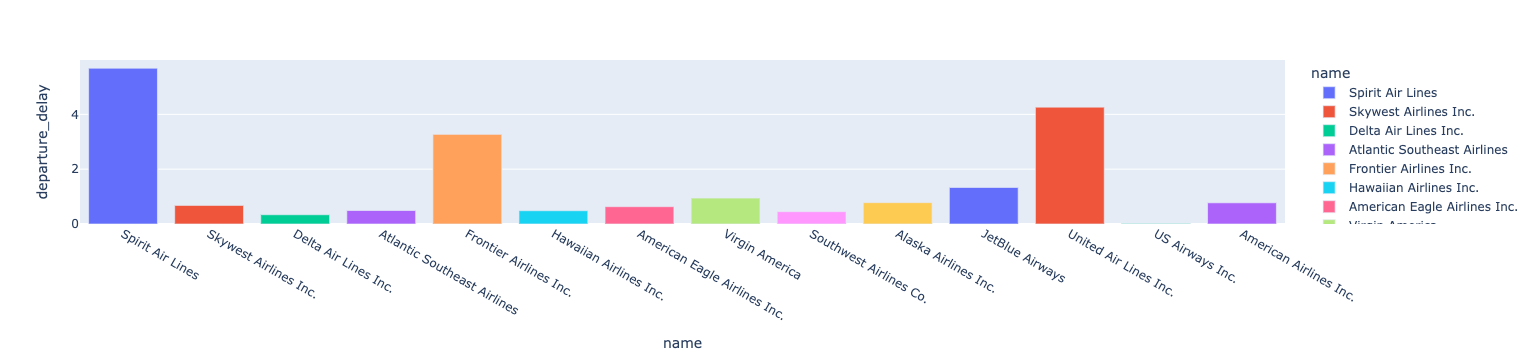

In [82]:
fig.show()

In [83]:
fig = px.bar(df, x='name', y='arrival_delay', color='name')

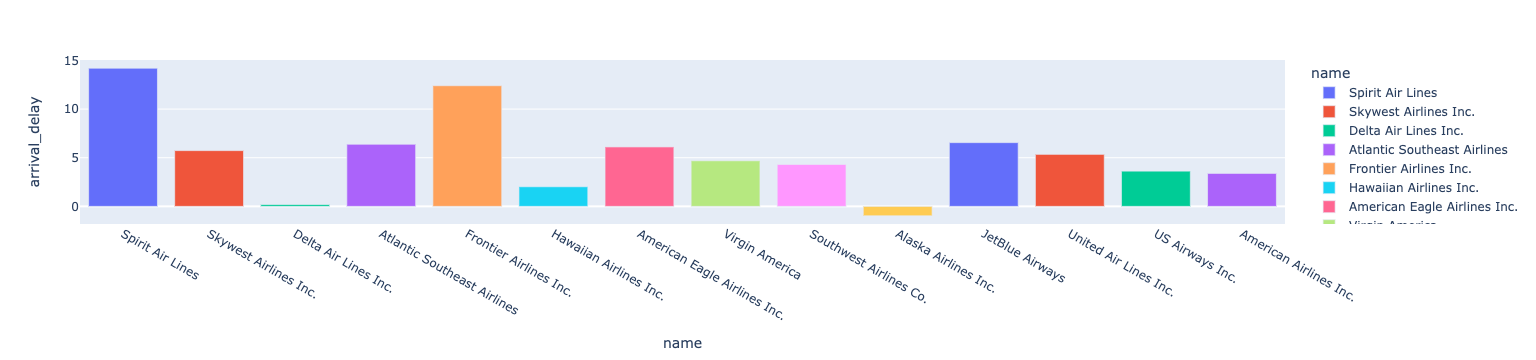

In [84]:
fig.show()

In [86]:
import plotly.graph_objects as go

In [87]:
fig = go.Figure(data=[go.Bar(x=df.name, y=df.departure_delay, name='departure_delay', marker_color='#ADDFBE'),
                      go.Bar(x=df.name, y=df.arrival_delay, name='arrival_delay', marker_color='#FF32B0')],
               layout=go.Layout(title='Average Arrival & Departue Delay by Airline', barmode='stack'))

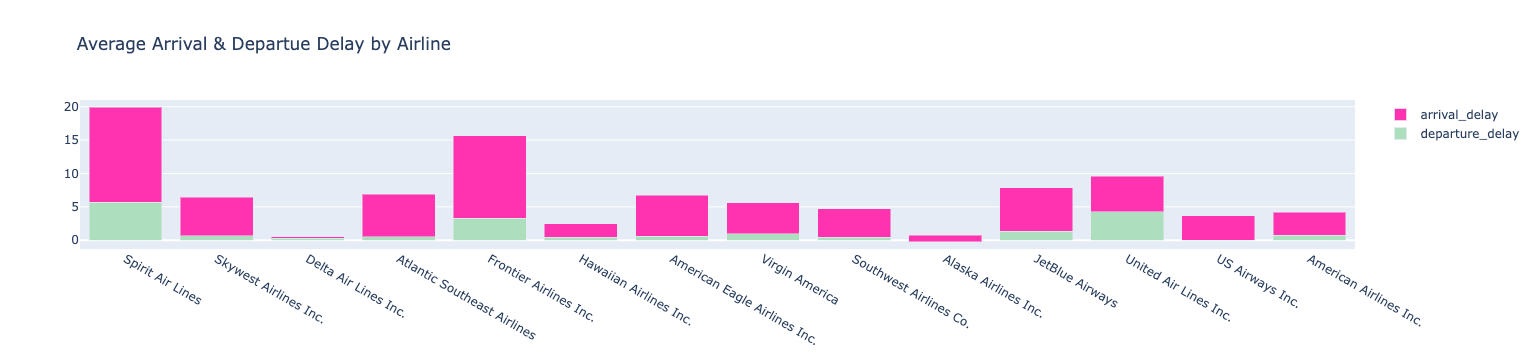

In [88]:
fig.show()